Q1.) Task 1

[nltk_data] Downloading package punkt to /home/suraj/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/suraj/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total Documents: 3
Total Tokens: 28089
Vocabulary Size: 5868
Tokens in Document 1: 968
Tokens in Document 2: 22507
Tokens in Document 3: 4614

Top 20 Frequent Words:
learning : 373
data : 347
computer : 301
course : 297
algorithms : 232
systems : 204
design : 204
science : 180
networks : 176
tech : 169
engineering : 161
elective : 155
computing : 153
level : 152
students : 151
edition : 149
analysis : 139
applications : 138
research : 133
department : 130


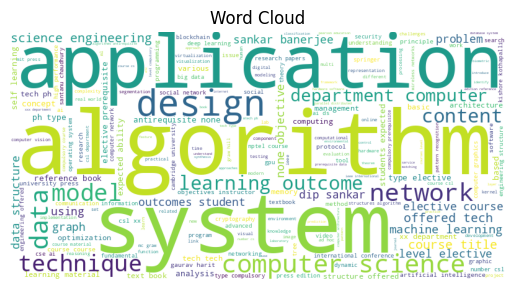

In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')

# Load data files data1.txt, data2.txt, data3.txt
def load_data(file_paths):
    corpus = []
    for path in file_paths:
        with open(path, 'r', encoding='utf-8') as f:
            corpus.append(f.read())
    return corpus



# Cleaning Docs data1, data2, data3
def clean_text(text):

    # Remove HTML tags (if any)
    text = re.sub(r'<.*?>', ' ', text)

    # Fix merged words from PDF extraction
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)

    # Remove non-ASCII characters
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    

    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    text = re.sub(r'\b[a-z]{1,2}\b', ' ', text)


    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Tokenization
def tokenize(text):
    return word_tokenize(text)



# Full preprocessing
def preprocess(corpus):
    stop_words = set(stopwords.words('english'))

    all_tokens = []
    doc_wise_tokens = []

    for doc in corpus:
        cleaned = clean_text(doc)
        tokens = tokenize(cleaned)

        # Noise words from PDF/web junk
        noise_words = {
            "pdf","page","pages","article","www","http","https",
            "lecture","lectures","overview","introduction",
            "rivest","turing","york","html","com","org"
        }

        tokens = [
            w for w in tokens
            if w not in stop_words
            and w not in noise_words
            and len(w) > 1   # TO keep ug, pg, ai
        ]

        all_tokens.extend(tokens)
        doc_wise_tokens.append(tokens)

    return all_tokens, doc_wise_tokens


# To get dataset statistics
def dataset_stats(all_tokens, doc_tokens):
    total_docs = len(doc_tokens)
    total_tokens = len(all_tokens)
    vocab = set(all_tokens)
    vocab_size = len(vocab)

    return total_docs, total_tokens, vocab_size


# Top frequent words
def top_words(tokens, k=20):
    """
    Returns top-k frequent words.
    """
    counter = Counter(tokens)
    return counter.most_common(k)


# STEP 7: Word Cloud (MANDATORY)
def generate_wordcloud(tokens):
    text = " ".join(tokens)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(text)

    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title("Word Cloud")
    plt.show()



files = ["data1.txt", "data2.txt", "data3.txt"]

# Load data
corpus = load_data(files)

# Preprocess
all_tokens, doc_tokens = preprocess(corpus)

# Statistics
total_docs, total_tokens, vocab_size = dataset_stats(all_tokens, doc_tokens)

print("Total Documents:", total_docs)
print("Total Tokens:", total_tokens)
print("Vocabulary Size:", vocab_size)

# Document-wise stats
for i, doc in enumerate(doc_tokens):
    print(f"Tokens in Document {i+1}:", len(doc))

# Top frequent words
print("\nTop 20 Frequent Words:")
for word, freq in top_words(all_tokens):
    print(word, ":", freq)

# Word Cloud generation
generate_wordcloud(all_tokens)


# Save clean corpus on disk
with open("clean_corpus.txt", "w", encoding="utf-8") as f:
    f.write(" ".join(all_tokens))

Q1) Task -2)

In [ ]:
from gensim.models import Word2Vec
import multiprocessing

# Load data
# Reads cleaned corpus and converts into sentences. Each line is treated as a sentence to preserve context.

def load_corpus(file_path):
    sentences = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            words = line.strip().split()
            if len(words) > 1:
                sentences.append(words)

    return sentences


# Train Word2Vec model
def train_model(sentences, model_type="cbow", dim=100, window=5, negative=5):

    sg = 0 if model_type == "cbow" else 1

    model = Word2Vec(
        sentences=sentences,
        vector_size=dim,
        window=window,
        negative=negative,
        sg=sg,
        workers=multiprocessing.cpu_count(),
        min_count=2,
        epochs=10
    )

    return model


# Evaluate model and rints vocabulary size and sample similarities.
def evaluate_model(model):

    print("Vocabulary size:", len(model.wv))

    test_words = ["research", "student", "learning"]

    for word in test_words:
        if word in model.wv:
            print(f"\nTop 5 words similar to '{word}':")
            for w, score in model.wv.most_similar(word, topn=5):
                print(w, ":", round(score, 4))



# Run experiments, Runs multiple configurations as required.
def run_experiments(sentences):

    configs = [
        {"dim": 50, "window": 3, "negative": 5},
        {"dim": 100, "window": 5, "negative": 5},
        {"dim": 200, "window": 8, "negative": 10}
    ]

    models = []

    for i, config in enumerate(configs):

        print("\n==============================")
        print("Experiment", i+1, config)
        print("==============================")

        # CBOW
        print("\nTraining CBOW...")
        cbow_model = train_model(
            sentences,
            "cbow",
            config["dim"],
            config["window"],
            config["negative"]
        )

        print("\nCBOW Evaluation:")
        evaluate_model(cbow_model)

        # Skip-gram
        print("\nTraining Skip-gram...")
        skip_model = train_model(
            sentences,
            "skipgram",
            config["dim"],
            config["window"],
            config["negative"]
        )

        print("\nSkip-gram Evaluation:")
        evaluate_model(skip_model)

        models.append((config, cbow_model, skip_model))

    return models


#Save models

def save_models(models):
    for i, (config, cbow, skip) in enumerate(models):
        cbow.save(f"cbow_model_{i}.model")
        skip.save(f"skipgram_model_{i}.model")



corpus_file = "clean_corpus.txt"

# Load sentences
sentences = load_corpus(corpus_file)

print("Total sentences:", len(sentences))

# Train models
models = run_experiments(sentences)

# Save models
save_models(models)

print("\nTraining completed successfully!")

Total sentences: 1

Experiment 1 {'dim': 50, 'window': 3, 'negative': 5}

Training CBOW...

CBOW Evaluation:
Vocabulary size: 2508

Top 5 words similar to 'research':
techniques : 0.9987
system : 0.9986
problems : 0.9985
learning : 0.9985
design : 0.9985

Top 5 words similar to 'student':
research : 0.9888
space : 0.9885
laboratory : 0.9884
evaluation : 0.9877
network : 0.9877

Top 5 words similar to 'learning':
techniques : 0.9989
machine : 0.9988
models : 0.9987
research : 0.9985
design : 0.9985

Training Skip-gram...

Skip-gram Evaluation:
Vocabulary size: 2508

Top 5 words similar to 'research':
projects : 0.9912
exams : 0.9911
demonstrate : 0.9898
etc : 0.9893
able : 0.9892

Top 5 words similar to 'student':
undergraduate : 0.9895
well : 0.9871
suffix : 0.9868
ug : 0.9865
ica : 0.9863

Top 5 words similar to 'learning':
deep : 0.9401
machine : 0.9341
understand : 0.8827
recognition : 0.8812
students : 0.8736

Experiment 2 {'dim': 100, 'window': 5, 'negative': 5}

Training CBOW...


In [2]:
from gensim.models import Word2Vec

# Load last trained skip-gram model
model = Word2Vec.load("skipgram_model_2.model")

# Word to check
word = "jodhpur"

# Get embedding
if word in model.wv:
    vector = model.wv[word]
    
    print(f"Embedding for '{word}':\n")
    print(vector)
    print("\nVector size:", len(vector))
else:
    print(f"'{word}' not found in vocabulary")

Embedding for 'jodhpur':

[ 0.07718624  0.09488647  0.05621307  0.0114364  -0.03902918  0.00355454
 -0.05720861 -0.06711674  0.08220351  0.13906859 -0.03328523 -0.1286434
  0.04376668  0.14760157 -0.05460161 -0.0214548  -0.01286943 -0.06309065
  0.12218378 -0.10182345  0.02839977 -0.13455199 -0.02584912  0.02659043
 -0.04008109 -0.13062246  0.06566725 -0.05579902 -0.0422958   0.04103221
 -0.09768122  0.05212541 -0.01363106 -0.1707373  -0.14165394  0.03903363
  0.1243731   0.03201119 -0.04918392 -0.2793548  -0.21739578  0.13672607
  0.11452162 -0.07357477  0.20259011 -0.15123095  0.03124579 -0.18757483
  0.23733644 -0.00522839  0.1348236   0.08672292 -0.10459798 -0.13657789
 -0.11616704 -0.02944179  0.1549972  -0.00692282 -0.0295604  -0.01201757
  0.06703642 -0.03917286 -0.16140556  0.1331432  -0.06296338 -0.01630752
 -0.11622968  0.08620421 -0.09230949  0.06582913  0.194773    0.01625449
  0.05681321  0.12234642  0.259661    0.03022273  0.15126753 -0.04896095
 -0.05678067 -0.15618354 -

In [ ]:
from gensim.models import Word2Vec

# Load model
def load_model(path):
    return Word2Vec.load(path)


# Nearest neighbors
def nearest_neighbors(model, words, model_name):
    print(f"\n========== {model_name} Nearest Neighbors ==========")

    for word in words:
        if word in model.wv:
            print(f"\nTop 5 neighbors for '{word}':")
            for w, score in model.wv.most_similar(word, topn=5):
                print(w, ":", round(score, 4))
        else:
            print(f"\nWord '{word}' not in vocabulary")


# Analogy
def analogy_tests(model, model_name):
    print(f"\n========== {model_name} Analogy Tests ==========")

    analogies = [
        ("btech", "ug", "pg"),
        ("student", "phd", "research"),
        ("course", "exam", "assignment")
    ]

    for a, b, c in analogies:
        if all(w in model.wv for w in [a, b, c]):
            result = model.wv.most_similar(
                positive=[c, a],
                negative=[b],
                topn=1
            )

            print(f"\n{b} : {a} :: {c} : ?")
            print("Answer:", result[0][0], "(", round(result[0][1], 4), ")")
        else:
            print(f"\nSkipping analogy ({a}, {b}, {c}) - word missing")



cbow_model = load_model("cbow_model_1.model")
skip_model = load_model("skipgram_model_1.model")

# Required words (include duplicate exam as per assignment)
test_words = ["research", "student", "phd", "exam", "exam"]

# CBOW
nearest_neighbors(cbow_model, test_words, "CBOW")
analogy_tests(cbow_model, "CBOW")

# Skip-gram
nearest_neighbors(skip_model, test_words, "Skip-gram")
analogy_tests(skip_model, "Skip-gram")


========== CBOW Nearest Neighbors ==========

Top 5 neighbors for 'research':
algorithm : 0.9998
programming : 0.9998
models : 0.9998
architecture : 0.9998
techniques : 0.9997

Top 5 neighbors for 'student':
languages : 0.9984
book : 0.9983
based : 0.9983
models : 0.9983
machines : 0.9983

Top 5 neighbors for 'phd':
text : 0.9978
based : 0.9978
problem : 0.9978
computational : 0.9978
theory : 0.9978

Top 5 neighbors for 'exam':
machine : 0.9969
evaluation : 0.9969
architecture : 0.9968
different : 0.9968
models : 0.9968

Top 5 neighbors for 'exam':
machine : 0.9969
evaluation : 0.9969
architecture : 0.9968
different : 0.9968
models : 0.9968

========== CBOW Analogy Tests ==========

ug : btech :: pg : ?
Answer: program ( 0.9959 )

phd : student :: research : ?
Answer: systems ( 0.9965 )

exam : course :: assignment : ?
Answer: courses ( 0.9956 )

========== Skip-gram Nearest Neighbors ==========

Top 5 neighbors for 'research':
student : 0.9718
academic : 0.9607
institute : 0.9603
wou

/home/suraj/.vscode-server/cuda/heysk/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/home/suraj/.vscode-server/cuda/heysk/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


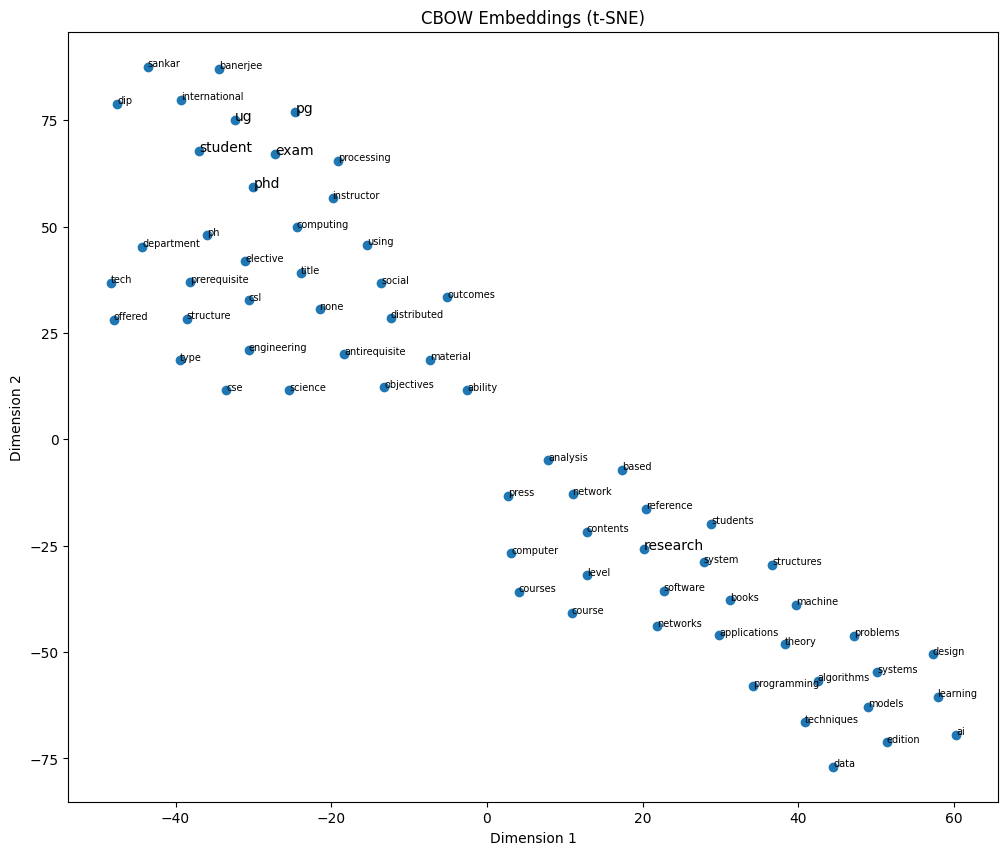

/home/suraj/.vscode-server/cuda/heysk/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/home/suraj/.vscode-server/cuda/heysk/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


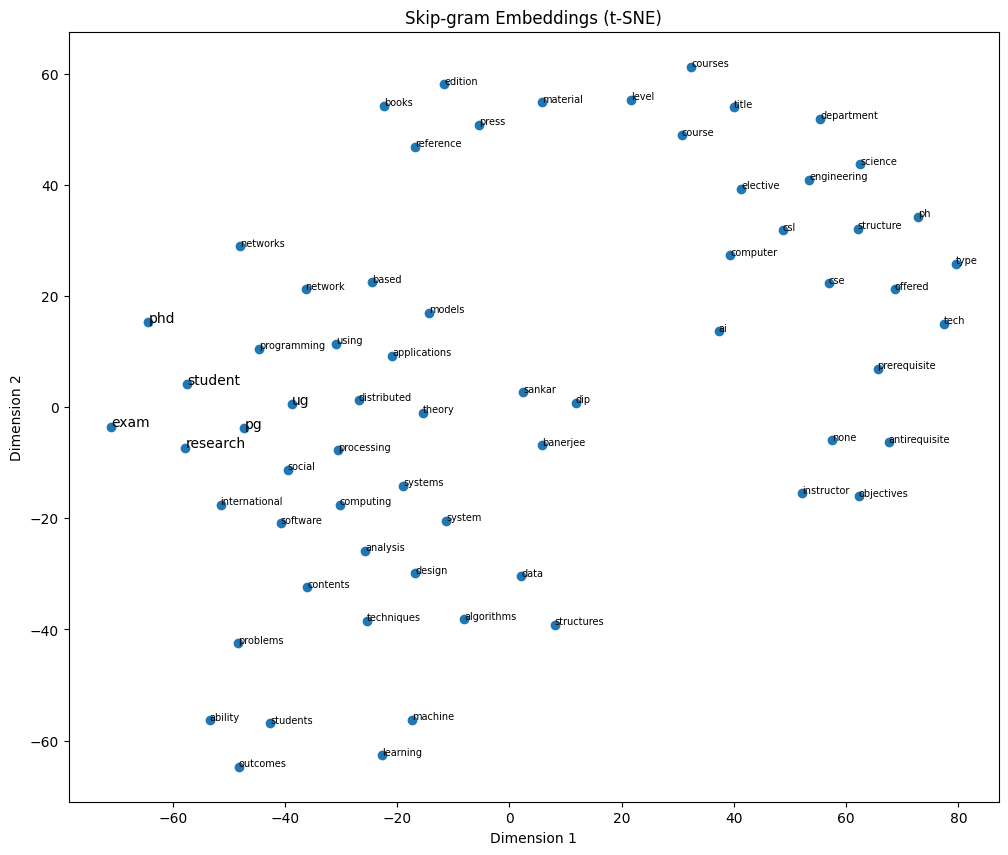

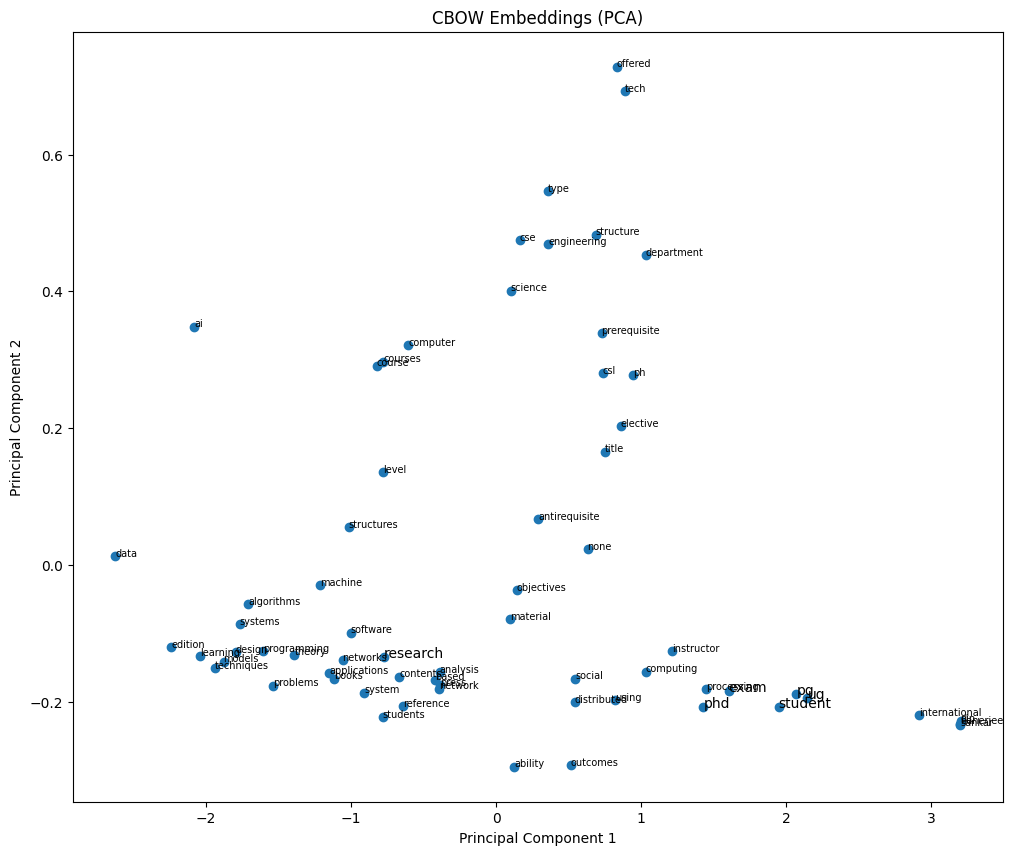

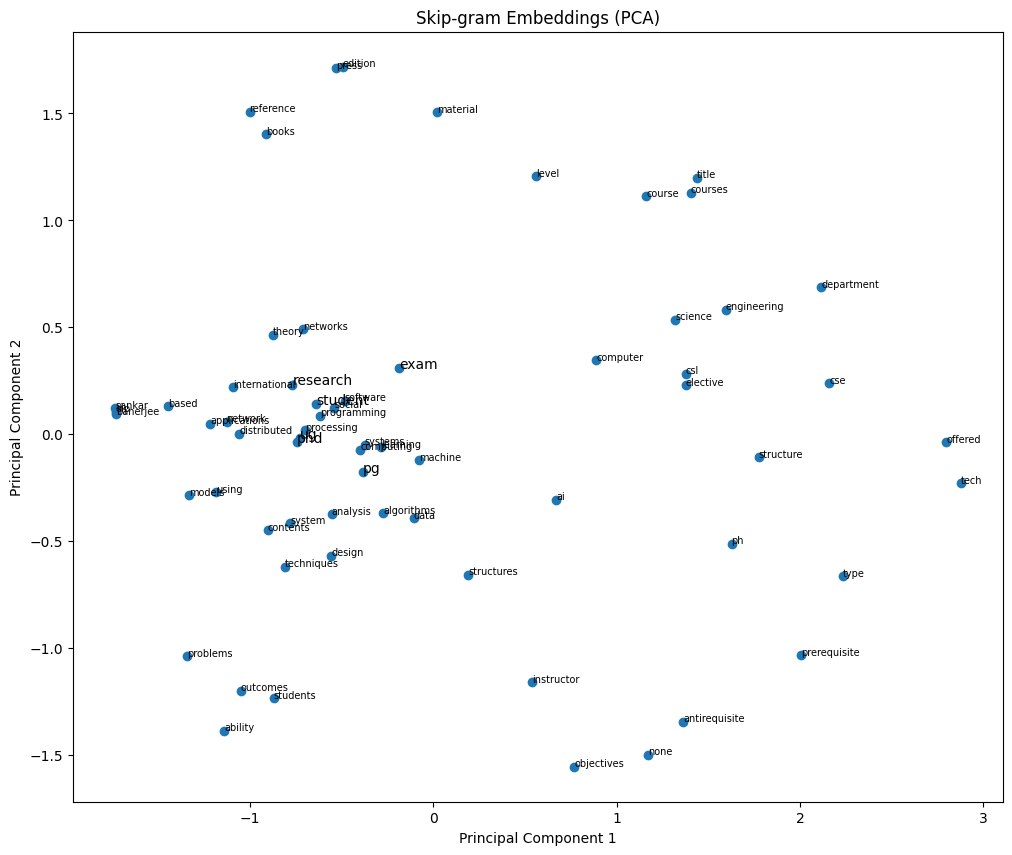

In [ ]:
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np

#Load models
def load_models():
    cbow = Word2Vec.load("cbow_model_1.model")
    skip = Word2Vec.load("skipgram_model_1.model")
    return cbow, skip

# Select words , Select words for visualization: Top frequent words + important academic words
def get_words(model, n=60):

    important_words = ["student", "ug", "pg", "phd", "exam", "research"]

    words = list(model.wv.index_to_key[:n])

    # Ensure important words are included
    for w in important_words:
        if w in model.wv and w not in words:
            words.append(w)

    return words

# Get embeddings
def get_vectors(model, words):
    return np.array([model.wv[word] for word in words])


# t-SNE Visualization (MAIN)
def tsne_plot(model, title):

    words = get_words(model, 60)
    vectors = get_vectors(model, words)

    # Ensure stable perplexity
    perp = min(30, len(words) // 3)

    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
    reduced = tsne.fit_transform(vectors)

    plt.figure(figsize=(12, 10))
    plt.scatter(reduced[:, 0], reduced[:, 1])

    # Highlight important words
    important_words = {"student", "ug", "pg", "phd", "exam", "research"}

    for i, word in enumerate(words):
        if word in important_words:
            plt.annotate(word, (reduced[i, 0], reduced[i, 1]), fontsize=10)
        else:
            plt.annotate(word, (reduced[i, 0], reduced[i, 1]), fontsize=7)

    plt.title(title)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.show()


# PCA Visualization
def pca_plot(model, title):

    words = get_words(model, 60)
    vectors = get_vectors(model, words)

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(12, 10))
    plt.scatter(reduced[:, 0], reduced[:, 1])

    important_words = {"student", "ug", "pg", "phd", "exam", "research"}

    for i, word in enumerate(words):
        if word in important_words:
            plt.annotate(word, (reduced[i, 0], reduced[i, 1]), fontsize=10)
        else:
            plt.annotate(word, (reduced[i, 0], reduced[i, 1]), fontsize=7)

    plt.title(title)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()



cbow_model, skip_model = load_models()

# t-SNE 
tsne_plot(cbow_model, "CBOW Embeddings (t-SNE)")
tsne_plot(skip_model, "Skip-gram Embeddings (t-SNE)")

# PCA 
pca_plot(cbow_model, "CBOW Embeddings (PCA)")
pca_plot(skip_model, "Skip-gram Embeddings (PCA)")

Interpretation of Clustering Behavior
A)  t-SNE Visualization

The t-SNE plots reveal how words are organized based on their semantic similarity in the embedding space.

In the Skip-gram model, clear and meaningful clusters are observed:
Words like “student”, “ug”, “pg”, “phd” are grouped together, indicating that the model captures the academic hierarchy.
Words such as “exam”, “assignment”, “course” appear close to each other, reflecting evaluation-related concepts.
“research” and “phd” are positioned nearby, showing strong semantic association.
In contrast, the CBOW model shows:
More scattered and loosely formed clusters
Weaker grouping of related academic terms
Less clear separation between different semantic categories

This indicates that Skip-gram captures richer semantic relationships, while CBOW provides more general representations.

B.) PCA Visualization
PCA projections show less distinct clustering compared to t-SNE.
Words are distributed more linearly, and clusters are not clearly separated.
However, some grouping of related words is still visible.
This is expected because:

PCA is a linear dimensionality reduction methoD
t-SNE captures non-linear relationships, making clusters more visible

C.) CBOW vs Skip-gram (Key Differences)
Aspect	-> CBOW	Skip-gram
Learning approach	->Predicts word from context	Predicts context from word
Speed ->	Faster	Slower
Rare word handling	-> Weak	Strong
Semantic quality ->	General	Rich & precise
Clustering (your result) ->	Scattered	Well-formed clusters


Finally we can say the, Skip-gram model produces embeddings that better capture semantic relationships, as evidenced by tighter and more meaningful clusters in the t-SNE visualization. CBOW, while computationally efficient, results in more diffuse embeddings with weaker semantic grouping.

